# ☕ EDA — Coffee Quality Classification
### Proyecto Grupal — Clasificación de Calidad de Café

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto de Machine Learning.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **0** | Importar librerías y cargar datos |
| **1** | Primera inspección del dataset |
| **2** | Análisis de valores nulos |
| **3** | Crear la variable objetivo (target) |
| **4** | Análisis de variables numéricas (sensoriales) |
| **5** | Análisis de variables categóricas (origen, proceso) |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Conclusiones y próximos pasos |

---

> ⚠️ **Importante:** Ejecuta las celdas en orden, de arriba a abajo. Cada celda depende de la anterior.

---
## 📦 BLOQUE 0 — Importar librerías y cargar el dataset

**¿Qué son las librerías?**  
Son colecciones de funciones ya escritas por otros que podemos reutilizar.  
- `pandas` → manipular tablas de datos  
- `numpy` → cálculos matemáticos  
- `matplotlib` y `seaborn` → crear gráficos  
- `warnings` → ocultar avisos que no nos interesan

In [1]:
# ─── Cargar de librerías  ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import warnings

In [2]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('../../data/processed/juanma/coffee_quality_fusion.csv')

print(f'✅ Dataset cargado correctamente')
print(f'📊 Dimensiones df: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset cargado correctamente
📊 Dimensiones df: 1512 filas x 38 columnas


---
## 🔍 BLOQUE 1 — Primera inspección del dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía.  
Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

In [3]:
# Ver las primeras 3 filas del dataset (head)
# Esto nos da una idea visual de cómo están organizados los datos
df.head(3)

,Acidity,Aftertaste,Aroma,Bag Weight,Balance,Body,Category One Defects,Category Two Defects,Certification Address,Certification Body,...,Processing Method,Producer,Quakers,Region,Sweetness,Total Cup Points,Uniformity,Variety,altitud_limpia,dataset_source
0,8.75,8.67,8.67,60 kg,8.42,8.50,0,0,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,...,Washed / Wet,METAD PLC,0.0,guji-hambela,10.0,90.58,10.0,NaN,2075.0,2018_volpatto
1,8.58,8.50,8.75,60 kg,8.42,8.42,0,1,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,...,Washed / Wet,METAD PLC,0.0,guji-hambela,10.0,89.92,10.0,Other,2075.0,2018_volpatto
2,8.42,8.42,8.42,1,8.42,8.33,0,0,36d0d00a3724338ba7937c52a378d085f2172daa,Specialty Coffee Association,...,NaN,NaN,0.0,NaN,10.0,89.75,10.0,Bourbon,1700.0,2018_volpatto


In [4]:
# Información general del dataset
# 'object' = texto | 'float64/int64' = número
print('ℹ️ Información del dataset:')
df.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Acidity                1512 non-null   float64
 1   Aftertaste             1512 non-null   float64
 2   Aroma                  1512 non-null   float64
 3   Bag Weight             1512 non-null   str    
 4   Balance                1512 non-null   float64
 5   Body                   1512 non-null   float64
 6   Category One Defects   1512 non-null   int64  
 7   Category Two Defects   1512 non-null   int64  
 8   Certification Address  1512 non-null   str    
 9   Certification Body     1512 non-null   str    
 10  Certification Contact  1512 non-null   str    
 11  Clean Cup              1512 non-null   float64
 12  Color                  1246 non-null   str    
 13  Company                1303 non-null   str    
 14  Country of Origin      1511 non-null   

In [5]:
# Estadísticas descriptivas de las columnas numéricas (describe)
# count=cuántos valores hay | mean=promedio | std=dispersión | min/max=extremos
df.describe()

,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Clean Cup,Flavor,Moisture Percentage,Number of Bags,Overall,Quakers,Sweetness,Total Cup Points,Uniformity,altitud_limpia
count,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1511.000000,1512.000000,1512.000000,1512.000000,1252.000000
mean,7.554762,7.425126,7.585251,7.534788,7.534716,0.388228,3.414021,9.855304,7.549120,1.546323,154.310185,7.522354,0.246856,9.916131,82.331892,9.854220,1320.215155
std,0.371842,0.396778,0.372107,0.392268,0.347892,1.722877,5.117211,0.720448,0.394165,3.690043,150.565226,0.460165,1.015418,0.495356,3.379424,0.524911,420.170125
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000
25%,7.330000,7.250000,7.420000,7.330000,7.330000,0.000000,0.000000,10.000000,7.330000,0.100000,10.000000,7.330000,0.000000,10.000000,81.420000,10.000000,1100.000000
50%,7.580000,7.420000,7.580000,7.580000,7.500000,0.000000,2.000000,10.000000,7.580000,0.110000,149.000000,7.500000,0.000000,10.000000,82.670000,10.000000,1320.000000
75%,7.750000,7.670000,7.750000,7.750000,7.750000,0.000000,4.000000,10.000000,7.750000,0.120000,275.000000,7.750000,0.000000,10.000000,83.830000,10.000000,1600.000000
max,8.750000,8.670000,8.750000,8.750000,8.580000,31.000000,55.000000,10.000000,8.830000,13.500000,2240.000000,10.000000,12.000000,10.000000,90.580000,10.000000,3500.000000


In [6]:
# MIO
# Ver todas las columnas, las object también
df.describe(include='object')

C:\Users\user\AppData\Local\Temp\ipykernel_14676\3184131762.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Bag Weight,Certification Address,Certification Body,Certification Contact,Color,Company,Country of Origin,Expiration,Farm Name,Grading Date,...,ICO Number,In-Country Partner,Lot Number,Mill,Owner,Processing Method,Producer,Region,Variety,dataset_source
count,1512,1512,1512,1512,1246,1303,1511,1512,1154,1512,...,1235,1512,473,1199,1505,1356,1281,1453,1306,1512
unique,72,51,35,48,6,340,37,631,724,632,...,904,36,404,604,384,12,833,460,62,2
top,1 kg,36d0d00a3724338ba7937c52a378d085f2172daa,Specialty Coffee Association,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,Green,"unex guatemala, s.a.",Mexico,"November 15th, 2023",various,"November 15th, 2022",...,0,Specialty Coffee Association,1,beneficio ixchel,juan luis alvarado romero,Washed / Wet,La Plata,huila,Caturra,2018_volpatto
freq,340,293,299,295,983,86,239,40,47,40,...,66,299,29,90,155,932,30,112,283,1305


In [7]:
# Ver el nombre de todas las columnas disponibles
df.columns

Index(['Acidity', 'Aftertaste', 'Aroma', 'Bag Weight', 'Balance', 'Body',
       'Category One Defects', 'Category Two Defects', 'Certification Address',
       'Certification Body', 'Certification Contact', 'Clean Cup', 'Color',
       'Company', 'Country of Origin', 'Expiration', 'Farm Name', 'Flavor',
       'Grading Date', 'Harvest Year', 'ICO Number', 'In-Country Partner',
       'Lot Number', 'Mill', 'Moisture Percentage', 'Number of Bags',
       'Overall', 'Owner', 'Processing Method', 'Producer', 'Quakers',
       'Region', 'Sweetness', 'Total Cup Points', 'Uniformity', 'Variety',
       'altitud_limpia', 'dataset_source'],
      dtype='str')

---
## 🕳️ BLOQUE 2 — Análisis de valores nulos

**¿Qué es un valor nulo?**  
Un valor nulo (NaN = Not a Number) es una celda vacía en nuestros datos.  
Ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [8]:
# Contar valores nulos por columna (isnull().sum())
df.isnull().sum()

Acidity                     0
Aftertaste                  0
Aroma                       0
Bag Weight                  0
Balance                     0
Body                        0
Category One Defects        0
Category Two Defects        0
Certification Address       0
Certification Body          0
Certification Contact       0
Clean Cup                   0
Color                     266
Company                   209
Country of Origin           1
Expiration                  0
Farm Name                 358
Flavor                      0
Grading Date                0
Harvest Year               46
ICO Number                277
In-Country Partner          0
Lot Number               1039
Mill                      313
Moisture Percentage         0
Number of Bags              0
Overall                     0
Owner                       7
Processing Method         156
Producer                  231
Quakers                     1
Region                     59
Sweetness                   0
Total Cup 

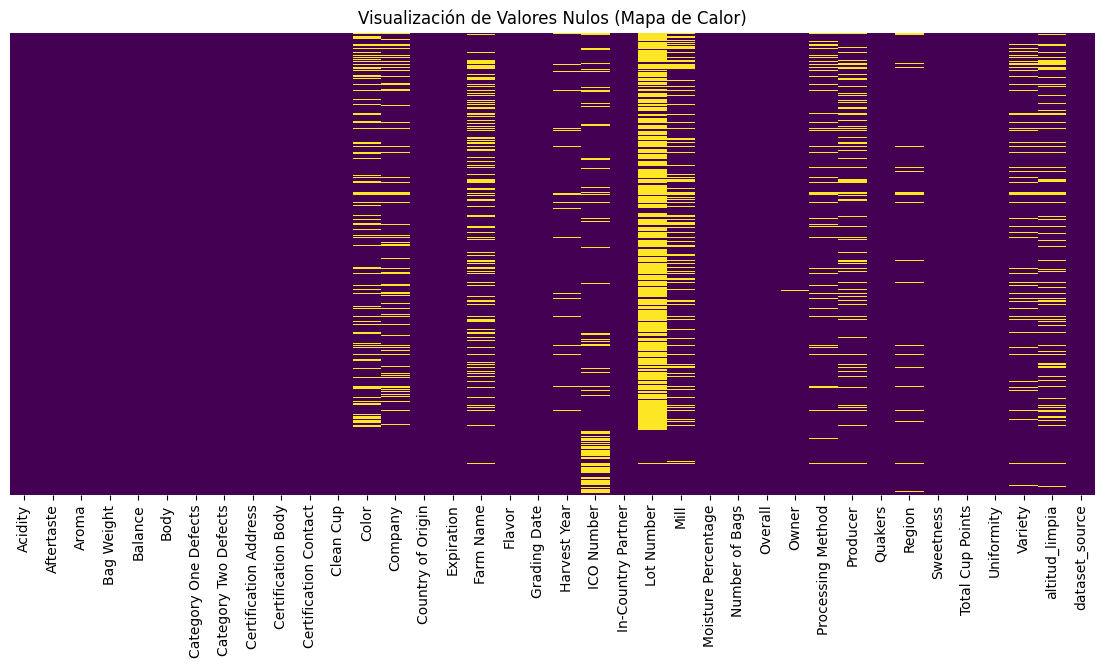

In [9]:
# Visualizar los nulos con un heatmap (Solo si lo ven necesario)

# 2. Configurar el tamaño de la figura (opcional pero recomendado)
plt.figure(figsize=(14, 6))

# 3. Crear el heatmap
# df.isnull() devuelve True donde hay nulos y False donde no
sn.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# 4. Mostrar el gráfico
plt.title("Visualización de Valores Nulos (Mapa de Calor)")
plt.show()

In [10]:
# Ver como estan distribuidos los datos por Color
df['Color'].value_counts()

Color
Green           983
Bluish-Green    133
Blue-Green       94
Yellow Green     17
Yellow           10
Brown             9
Name: count, dtype: int64

In [11]:
# Ver como estan distribuidos los datos por Country of Origin
df['Country of Origin'].value_counts()

Country of Origin
Mexico                          239
Guatemala                       202
Colombia                        202
Brazil                          142
Taiwan                          134
United States (Hawaii)           78
Honduras                         65
Costa Rica                       59
Ethiopia                         55
Tanzania, United Republic Of     46
Thailand                         44
Nicaragua                        32
Uganda                           29
El Salvador                      28
Kenya                            27
Indonesia                        23
China                            15
Peru                             14
Vietnam                          11
Malawi                           11
Myanmar                           9
United States                     8
Panama                            6
Haiti                             6
Laos                              6
Philippines                       5
United States (Puerto Rico)       4
Burundi   

In [12]:
# Ver como estan distribuidos los datos por altitud_limpia
df['altitud_limpia'].value_counts()

altitud_limpia
1200.0    89
1400.0    62
1300.0    58
1100.0    57
1600.0    48
          ..
140.0      1
1725.0     1
460.0      1
1574.0     1
435.0      1
Name: count, Length: 220, dtype: int64

In [13]:
# Ver como estan distribuidos los datos por Variety
df['Variety'].value_counts()

Variety
Caturra                           283
Bourbon                           243
Typica                            232
Other                             108
Catuai                             85
                                 ... 
Santander                           1
Typica Bourbon Caturra Catimor      1
Caturra,Colombia,Castillo           1
Castillo,Caturra,Bourbon            1
Catuai And Mundo Novo               1
Name: count, Length: 62, dtype: int64

In [14]:
# Ver como estan distribuidos los datos por Processing Method
df['Processing Method'].value_counts()

Processing Method
Washed / Wet                            932
Natural / Dry                           297
Semi-Washed / Semi-Pulped                55
Pulped Natural / Honey                   39
Other                                    26
Double Anaerobic Washed                   1
Semi Washed                               1
Honey,Mossto                              1
Double Carbonic Maceration / Natural      1
Wet Hulling                               1
Anaerobico 1000H                          1
Semi-Lavado                               1
Name: count, dtype: int64

In [15]:
# Ver como estan distribuidos los datos por Harvest Year
df['Harvest Year'].value_counts()

Harvest Year
2012                        351
2014                        226
2013                        170
2015                        124
2016                        121
2021 / 2022                  99
2017                         68
2022                         48
2022 / 2023                  42
2015/2016                    28
2013/2014                    27
2011                         26
2017 / 2018                  20
2014/2015                    19
2021                         13
2009/2010                    12
2010                         10
2010-2011                     6
2016 / 2017                   6
4T/10                         4
March 2010                    3
2009-2010                     3
4T/2010                       3
Mayo a Julio                  3
2023                          3
2011/2012                     2
January 2011                  2
Abril - Julio                 2
08/09 crop                    2
Sept 2009 - April 2010        1
May-August                 

In [16]:
df.columns

Index(['Acidity', 'Aftertaste', 'Aroma', 'Bag Weight', 'Balance', 'Body',
       'Category One Defects', 'Category Two Defects', 'Certification Address',
       'Certification Body', 'Certification Contact', 'Clean Cup', 'Color',
       'Company', 'Country of Origin', 'Expiration', 'Farm Name', 'Flavor',
       'Grading Date', 'Harvest Year', 'ICO Number', 'In-Country Partner',
       'Lot Number', 'Mill', 'Moisture Percentage', 'Number of Bags',
       'Overall', 'Owner', 'Processing Method', 'Producer', 'Quakers',
       'Region', 'Sweetness', 'Total Cup Points', 'Uniformity', 'Variety',
       'altitud_limpia', 'dataset_source'],
      dtype='str')

In [17]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres
df = df.drop(['Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Region', 'Producer', 'Number of Bags', 'dataset_source'], axis=1)
df = df.drop(['Bag Weight', 'Grading Date', 'Owner', 'Quakers', 'Expiration', 'Certification Body', 'Certification Address', 'Certification Contact'], axis=1)
df = df.drop(['In-Country Partner', 'Moisture Percentage', 'Overall'], axis=1)

In [18]:
# Comprobar las columnas resultantes
df.columns

Index(['Acidity', 'Aftertaste', 'Aroma', 'Balance', 'Body',
       'Category One Defects', 'Category Two Defects', 'Clean Cup', 'Color',
       'Country of Origin', 'Flavor', 'Harvest Year', 'Processing Method',
       'Sweetness', 'Total Cup Points', 'Uniformity', 'Variety',
       'altitud_limpia'],
      dtype='str')

---
## 🎯 BLOQUE 3 — Crear la variable objetivo (TARGET)

**¿Qué es el target?**  
Es la variable que queremos predecir. En nuestro caso, si un lote de café es **Specialty** o **No Specialty**.

**¿Cómo lo creamos?**  
Usamos el estándar oficial de la **Specialty Coffee Association (SCA)**:  
- `Total Cup Points >= 82.5` → **Specialty** (calidad premium)  
- `Total Cup Points < 82.5` → **No Specialty** (calidad estándar)

**⚠️ MUY IMPORTANTE:**  
Después de crear el target, debemos **eliminar `Total.Cup.Points` del dataset**.  
Si no lo hacemos, el modelo va a hacer trampa (data leakage) porque el target viene directamente de esa columna.

In [19]:
df[df['Total Cup Points'] >= 82.5]['Total Cup Points'].count()

np.int64(834)

In [20]:
df[df['Total Cup Points'] < 82.5]['Total Cup Points'].count()

np.int64(678)

In [21]:
# Crear la columna target usando el umbral de la SCA ()
UMBRAL_SPECIALTY = 82.5

# Si "total cup point" supera el limite es Specialty sino No Specialty
df['Specialty'] = np.where(df['Total Cup Points'] >= 82.5, 'Specialty', 'No Specialty')
df.head(3)

,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Clean Cup,Color,Country of Origin,Flavor,Harvest Year,Processing Method,Sweetness,Total Cup Points,Uniformity,Variety,altitud_limpia,Specialty
0,8.75,8.67,8.67,8.42,8.50,0,0,10.0,Green,Ethiopia,8.83,2014,Washed / Wet,10.0,90.58,10.0,NaN,2075.0,Specialty
1,8.58,8.50,8.75,8.42,8.42,0,1,10.0,Green,Ethiopia,8.67,2014,Washed / Wet,10.0,89.92,10.0,Other,2075.0,Specialty
2,8.42,8.42,8.42,8.42,8.33,0,0,10.0,NaN,Guatemala,8.50,NaN,NaN,10.0,89.75,10.0,Bourbon,1700.0,Specialty


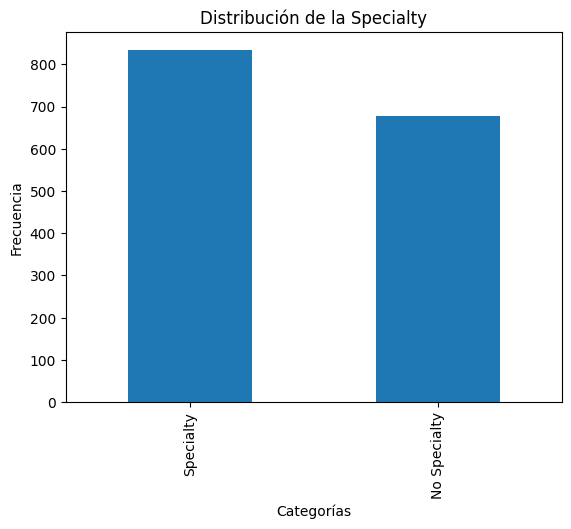

In [22]:
# Visualizar la distribución del target
# Si hay muchas más muestras de una clase que de otra = dataset DESBALANCEADO
# Un dataset desbalanceado puede engañar al modelo
# Además eliminamos Total cup Points.

# Contar valores y graficar
df['Specialty'].value_counts().plot(kind='bar')
plt.title('Distribución de la Specialty')
plt.ylabel('Frecuencia')
plt.xlabel('Categorías')
plt.show()

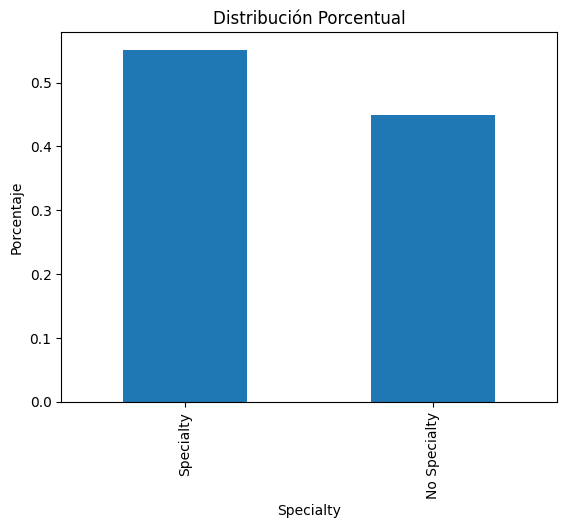

In [23]:
# Visualizar el tanto por ciento del target
df['Specialty'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribución Porcentual')
plt.ylabel('Porcentaje')
plt.show()

In [24]:
# Eliminar columna Total Cup Points
df.drop('Total Cup Points', axis=1, inplace=True)
df.head(3)

,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Clean Cup,Color,Country of Origin,Flavor,Harvest Year,Processing Method,Sweetness,Uniformity,Variety,altitud_limpia,Specialty
0,8.75,8.67,8.67,8.42,8.50,0,0,10.0,Green,Ethiopia,8.83,2014,Washed / Wet,10.0,10.0,NaN,2075.0,Specialty
1,8.58,8.50,8.75,8.42,8.42,0,1,10.0,Green,Ethiopia,8.67,2014,Washed / Wet,10.0,10.0,Other,2075.0,Specialty
2,8.42,8.42,8.42,8.42,8.33,0,0,10.0,NaN,Guatemala,8.50,NaN,NaN,10.0,10.0,Bourbon,1700.0,Specialty


---
## 📊 BLOQUE 4 — Análisis de variables numéricas (sensoriales)

**Objetivo:** Entender cómo se distribuyen las puntuaciones sensoriales y si hay diferencias entre cafés Specialty y No Specialty.

**¿Qué vamos a ver?**
- **Histograma:** Distribución de cada puntuación ¿es normal? ¿está sesgada?
- **Boxplot:** Comparación entre categorías de calidad
- **Violinplot:** Distribución completa por categoría

In [ ]:
# Definir las columnas sensoriales que vamos a analizar (Las variables que tenemos en Kaggel que influyen a nuestro modelo)
# Estas son las que un Q-Grader evalúa al catar un café

# Columnas Numéricas a revisar : Aroma, Flavor, Aftertaste, Acidity, Body, Balance, Uniformity, Clean Cup, Sweetness, altitud_limpia
# Category One Defects, Category Two Defects
# Columnas categoricar a revisar : Color, Variety

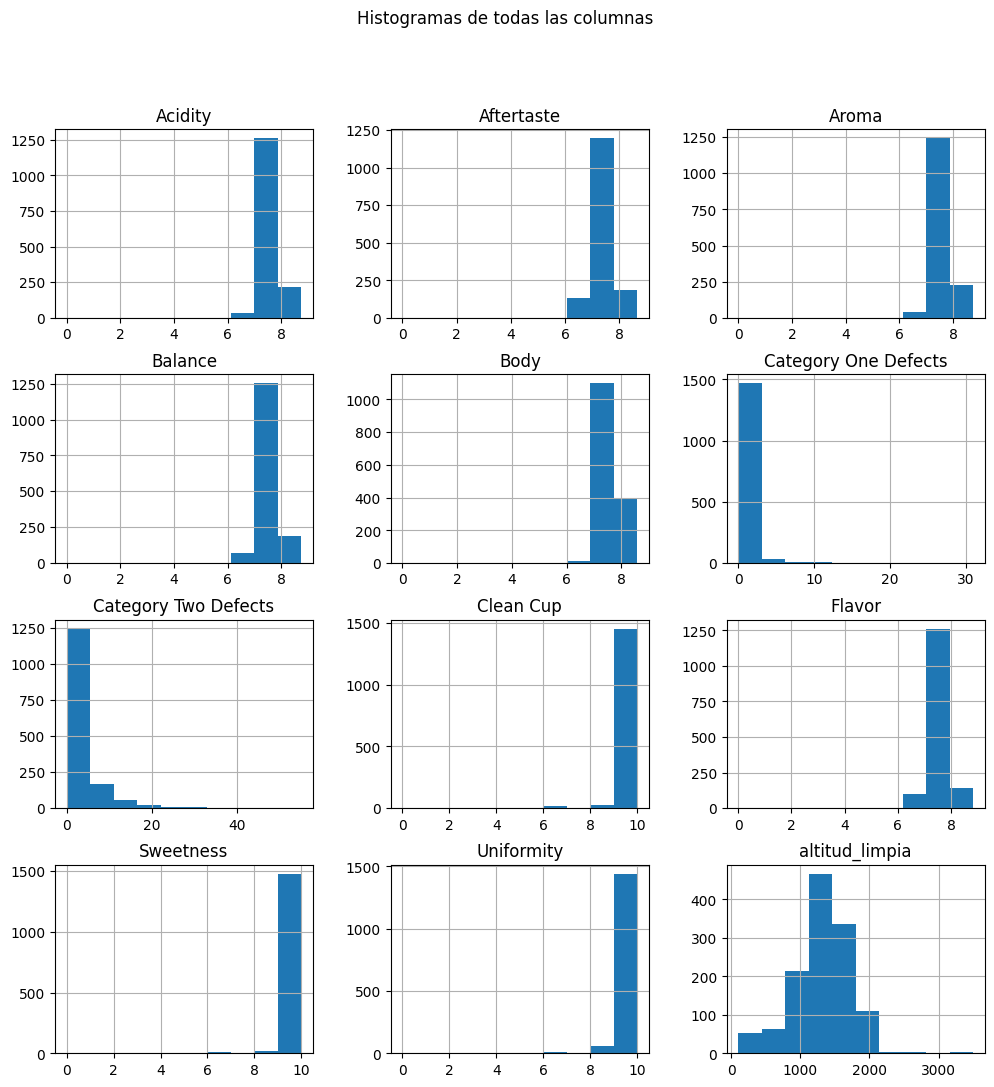

In [25]:
# ─── HISTOGRAMAS ──────────────────────────────────────────────────────────────
# Un histograma muestra cuántas muestras hay en cada rango de valores
# Ideal: distribución en forma de campana (normal)
# Si está muy sesgada hacia un lado, puede indicar outliers

# Crea un histograma para cada columna numérica del DataFrame
df.hist(bins=10, figsize=(12, 12))
plt.suptitle('Histogramas de todas las columnas')
plt.show()

In [105]:
# Agregar las gráficas que consideren necesarias.

---
## 🌍 BLOQUE 5 — Análisis de variables categóricas

**Variables categóricas:** Son las que tienen texto, como el país de origen, la variedad o el método de procesado.

**Objetivo:** Entender si el origen o el proceso del café influye en la calidad final.

EStos son solo ejemplo si ven necesarios pueden hacer sus propias preguntas y explorar.

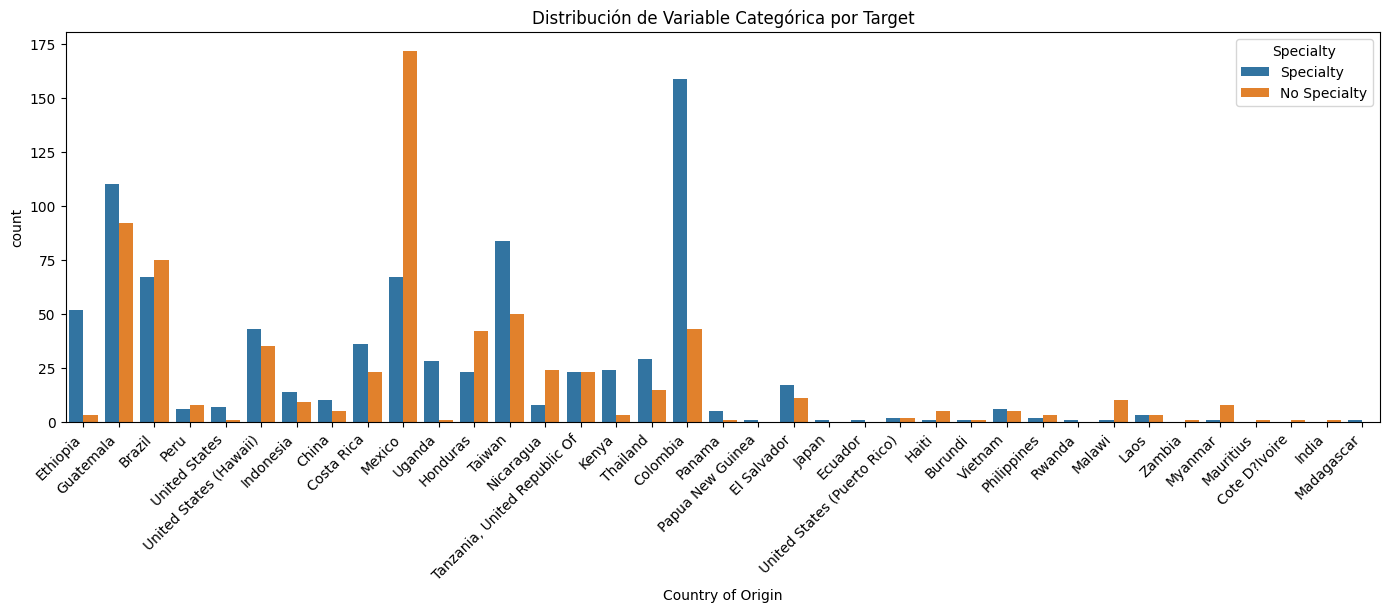

In [26]:
# ─── ANÁLISIS POR PAÍS DE ORIGEN ─────────────────────────────────────────────
# ¿Qué países producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Country of Origin', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

In [27]:
# ─── TASA DE SPECIALTY POR PAÍS ───────────────────────────────────────────────
# ¿Hay países donde una mayor proporción de su café es Specialty?

df['tasa_specialty'] = (df['Specialty'] == 'Specialty').astype(int)

tasa_por_pais = df.groupby('Country of Origin')['tasa_specialty'].mean()

tasa_por_pais_pct = tasa_por_pais * 100

tasa = pd.DataFrame(tasa_por_pais_pct)
tasa_ordenada = tasa.sort_values(by='tasa_specialty', ascending=False)

print("\nPorcentaje de Specialty por país:")
tasa_ordenada


Porcentaje de Specialty por país:


,tasa_specialty
Country of Origin,
Rwanda,100.000000
Papua New Guinea,100.000000
Madagascar,100.000000
Japan,100.000000
Ecuador,100.000000
Uganda,96.551724
Ethiopia,94.545455
Kenya,88.888889
United States,87.500000


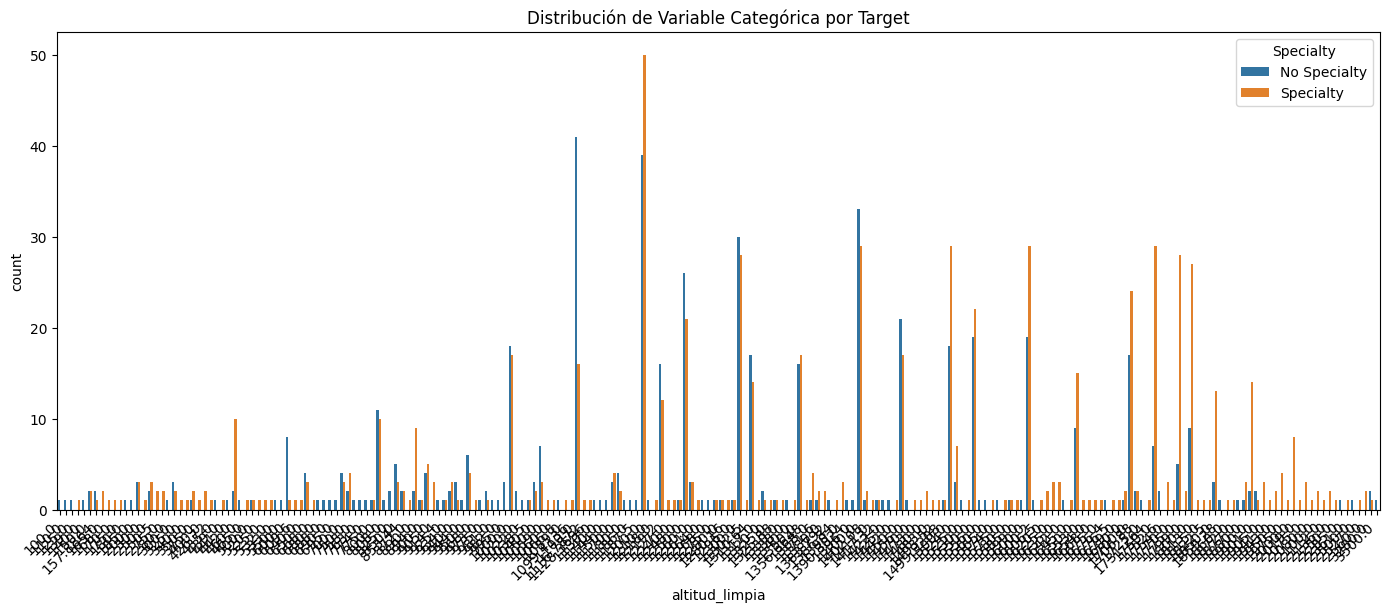

In [28]:
# ─── ANÁLISIS POR PAÍS DE ALTITUD ─────────────────────────────────────────────
# ¿Qué altitudes producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='altitud_limpia', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

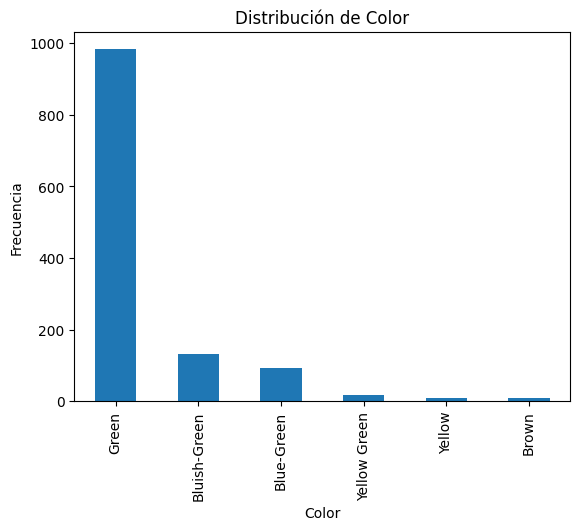

In [29]:
# Distribución de la variable Color

df['Color'].value_counts().plot(kind='bar')
plt.title('Distribución de Color')
plt.ylabel('Frecuencia')
plt.xlabel('Color')
plt.show()

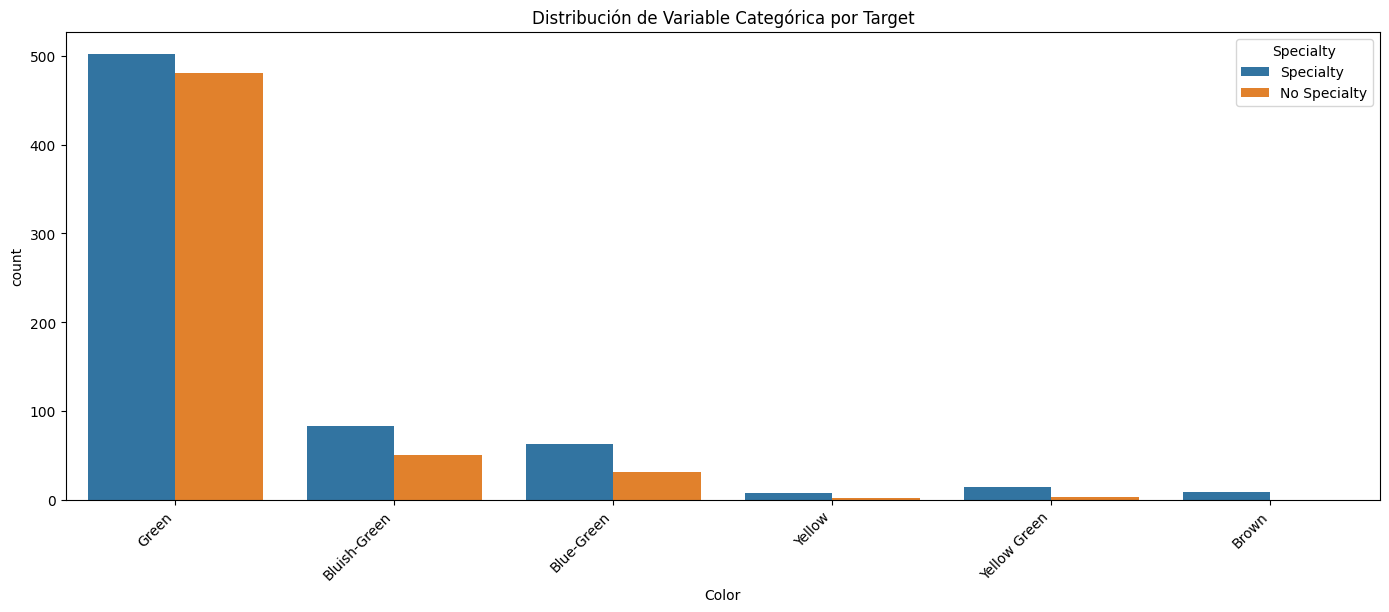

In [30]:
# ─── ANÁLISIS POR PAÍS DE COLOR ─────────────────────────────────────────────
# ¿Qué colores producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Color', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

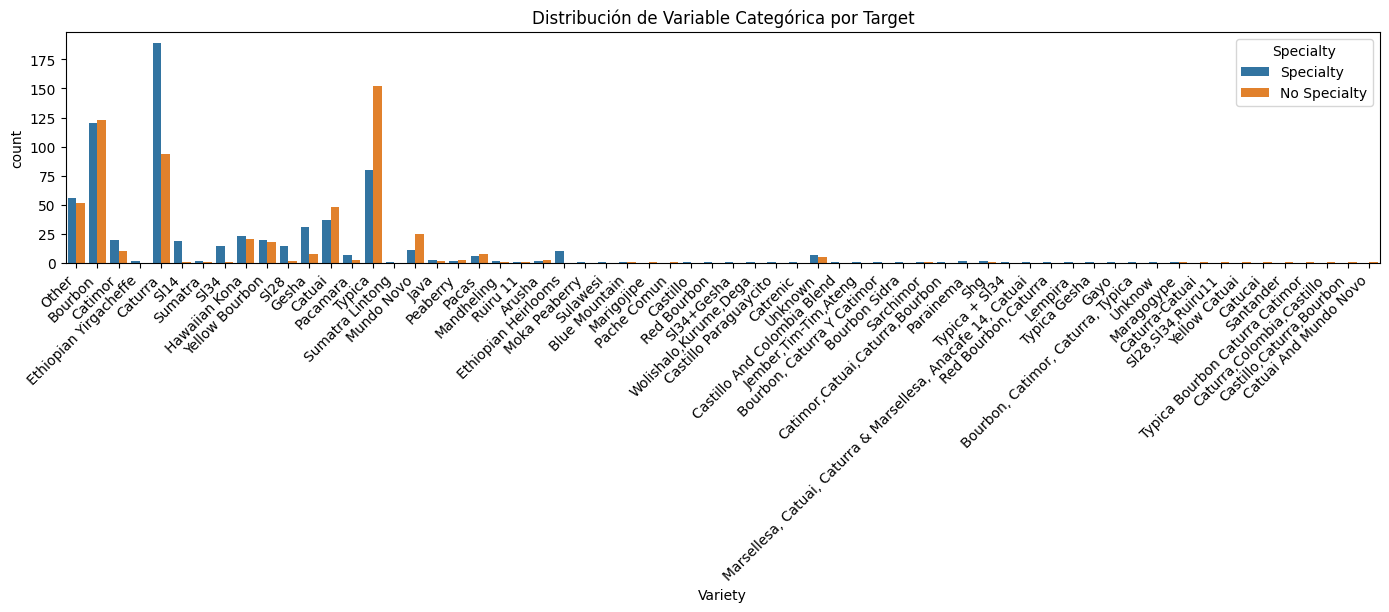

In [31]:
# ─── ANÁLISIS POR PAÍS DE VARIEDAD ─────────────────────────────────────────────
# ¿Qué variedades producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Variety', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

---
## 🔥 BLOQUE 6 — Matriz de correlación

**¿Qué es la correlación?**  
Mide cuánto se relacionan dos variables numéricas entre sí.  
- Correlación `+1` → cuando una sube, la otra también sube (relación perfecta positiva)  
- Correlación `-1` → cuando una sube, la otra baja (relación perfecta negativa)  
- Correlación `0` → no hay relación

**¿Para qué sirve en ML?**
- Identificar qué variables tienen más relación con el target
- Detectar variables muy correlacionadas entre sí (redundantes) — puede ser mejor eliminar una

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Acidity               1512 non-null   float64
 1   Aftertaste            1512 non-null   float64
 2   Aroma                 1512 non-null   float64
 3   Balance               1512 non-null   float64
 4   Body                  1512 non-null   float64
 5   Category One Defects  1512 non-null   int64  
 6   Category Two Defects  1512 non-null   int64  
 7   Clean Cup             1512 non-null   float64
 8   Color                 1246 non-null   str    
 9   Country of Origin     1511 non-null   str    
 10  Flavor                1512 non-null   float64
 11  Harvest Year          1466 non-null   str    
 12  Processing Method     1356 non-null   str    
 13  Sweetness             1512 non-null   float64
 14  Uniformity            1512 non-null   float64
 15  Variety               1306 non-n

In [33]:
# ─── HEATMAP DE CORRELACIÓN ───────────────────────────────────────────────────
# Solo calculamos correlación entre columnas numéricas

# Seleccionar solo las columnas numéricas
#df_correlacion = df.select_dtypes(include=['float64', 'int64'])
df_correlacion = df[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Category One Defects', 'Category Two Defects', 'altitud_limpia', 'Specialty']]

# Mapear valores: No Specialty=0, Specialty=1
df_correlacion['Specialty'] = df_correlacion['Specialty'].map({'No Specialty': 0, 'Specialty': 1})

matriz_corr = df_correlacion.corr()

print(matriz_corr)

                         Aroma    Flavor  Aftertaste   Acidity      Body  \
Aroma                 1.000000  0.818943    0.783525  0.729444  0.696380   
Flavor                0.818943  1.000000    0.897478  0.820332  0.763603   
Aftertaste            0.783525  0.897478    1.000000  0.798824  0.763316   
Acidity               0.729444  0.820332    0.798824  1.000000  0.739114   
Body                  0.696380  0.763603    0.763316  0.739114  1.000000   
Balance               0.722231  0.806611    0.827292  0.749721  0.773484   
Uniformity            0.358288  0.402907    0.394242  0.367804  0.335000   
Clean Cup             0.327847  0.388703    0.379511  0.296963  0.284644   
Sweetness             0.319400  0.354193    0.336909  0.325370  0.321732   
Category One Defects -0.080843 -0.064947   -0.084120 -0.070005 -0.020414   
Category Two Defects -0.164435 -0.211469   -0.226709 -0.151897 -0.107382   
altitud_limpia        0.134598  0.126355    0.122248  0.160784  0.137962   
Specialty   

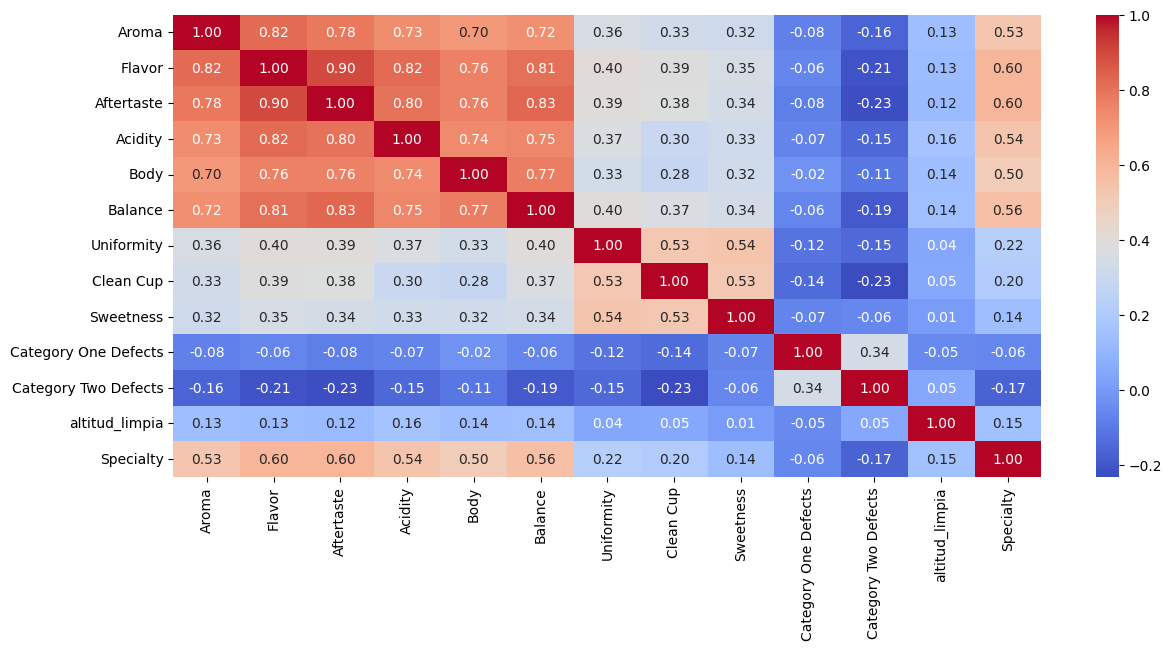

In [34]:
# 3. Pintar la matriz con Seaborn
plt.figure(figsize=(14, 6))
sn.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

---
## 🎯 BLOQUE 7 — Detección de Outliers

**¿Qué es un outlier?**  
Es un valor extremo que está muy alejado del resto.  
Por ejemplo: si todos los cafés tienen entre 7 y 9 puntos de aroma y hay uno con 1.5, ese es un outlier.

**¿Por qué importa?**  
Los outliers pueden distorsionar el modelo, haciéndolo aprender de casos excepcionales en lugar de la norma.

**Método IQR:**  
Se considera outlier cualquier valor fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`

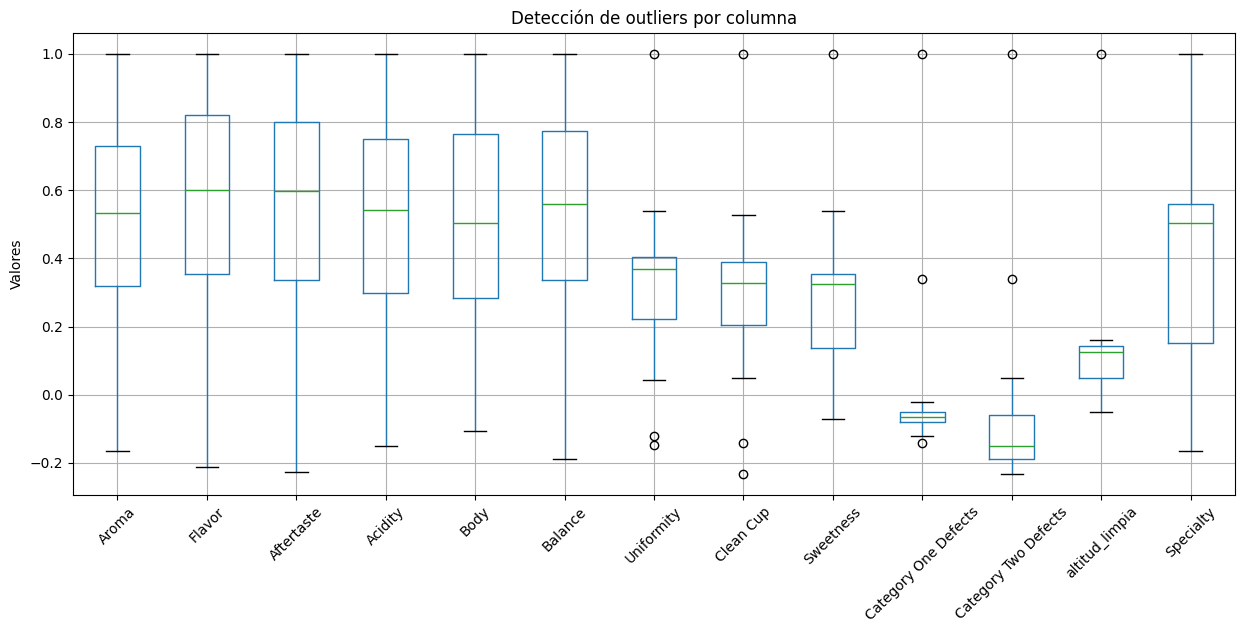

In [35]:
# ─── BOXPLOTS PARA DETECTAR OUTLIERS ─────────────────────────────────────────
# Los puntos fuera de los "bigotes" del boxplot son outliers
# Crear el boxplot
matriz_corr.boxplot(figsize=(15, 6))
plt.title('Detección de outliers por columna')
plt.ylabel('Valores')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────
# Para calcular si es correcto con las formulas vistas en clase (solo si ven outliers)

# Valorar los datos numéricos [Uniformity, Clean Cup, altitud_limpia]

In [36]:
# Verficar Uniformity

# 1. Calcular cuartiles Q1 y Q3
Q1 = df['Uniformity'].quantile(0.25)
Q3 = df['Uniformity'].quantile(0.75)

# 2. Calcular IQR
IQR = Q3 - Q1

# 3. Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Cuantificar/Filtrar valores atípicos
outliers = df[(df['Uniformity'] < limite_inferior) | (df['Uniformity'] > limite_superior)]

print("----------------- Uniformity --------------------")
print(f"Cuartil 1 (Q1): {Q1}")
print(f"Cuartil 3 (Q3): {Q3}")
print(f"IQR: {IQR}")
print(f"Límite Inferior: {limite_inferior}")
print(f"Límite Superior: {limite_superior}")
print("-" * 30)
print(f"Número de outliers: {len(outliers)}")
print("Valores atípicos:")
print(outliers)

----------------- Uniformity --------------------
Cuartil 1 (Q1): 10.0
Cuartil 3 (Q3): 10.0
IQR: 0.0
Límite Inferior: 10.0
Límite Superior: 10.0
------------------------------
Número de outliers: 185
Valores atípicos:
      Acidity  Aftertaste  Aroma  Balance  Body  Category One Defects  \
8        8.42        8.58   8.67     8.42  8.33                     0   
14       8.25        8.50   8.25     8.75  8.58                     0   
17       8.33        8.25   8.17     8.33  8.42                     0   
61       8.33        7.83   8.33     8.25  8.00                     0   
90       8.00        7.42   8.42     7.92  7.92                     2   
...       ...         ...    ...      ...   ...                   ...   
1302     6.25        6.33   7.25     6.08  6.42                     1   
1303     7.67        6.67   7.50     6.67  7.33                     0   
1304     0.00        0.00   0.00     0.00  0.00                     0   
1390     7.75        7.67   7.92     8.00  7.75     

In [37]:
# Verficar Clean Cup

# 1. Calcular cuartiles Q1 y Q3
Q1 = df['Clean Cup'].quantile(0.25)
Q3 = df['Clean Cup'].quantile(0.75)

# 2. Calcular IQR
IQR = Q3 - Q1

# 3. Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Cuantificar/Filtrar valores atípicos
outliers = df[(df['Clean Cup'] < limite_inferior) | (df['Clean Cup'] > limite_superior)]

print("----------------- Clean Cup --------------------")
print(f"Cuartil 1 (Q1): {Q1}")
print(f"Cuartil 3 (Q3): {Q3}")
print(f"IQR: {IQR}")
print(f"Límite Inferior: {limite_inferior}")
print(f"Límite Superior: {limite_superior}")
print("-" * 30)
print(f"Número de outliers: {len(outliers)}")
print("Valores atípicos:")
print(outliers)

----------------- Clean Cup --------------------
Cuartil 1 (Q1): 10.0
Cuartil 3 (Q3): 10.0
IQR: 0.0
Límite Inferior: 10.0
Límite Superior: 10.0
------------------------------
Número de outliers: 117
Valores atípicos:
      Acidity  Aftertaste  Aroma  Balance  Body  Category One Defects  \
61       8.33        7.83   8.33     8.25  8.00                     0   
93       8.00        7.92   8.08     8.00  8.08                     1   
254      8.42        8.17   7.92     8.17  8.08                     0   
303      7.67        7.83   7.83     8.17  8.00                     0   
329      7.67        7.83   8.17     7.75  8.08                     0   
...       ...         ...    ...      ...   ...                   ...   
1300     7.42        6.25   7.08     6.75  7.25                     0   
1301     6.67        6.42   6.75     6.67  7.08                     8   
1302     6.25        6.33   7.25     6.08  6.42                     1   
1303     7.67        6.67   7.50     6.67  7.33      

In [38]:
# Verficar altitud_limpia

# 1. Calcular cuartiles Q1 y Q3
Q1 = df['altitud_limpia'].quantile(0.25)
Q3 = df['altitud_limpia'].quantile(0.75)

# 2. Calcular IQR
IQR = Q3 - Q1

# 3. Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Cuantificar/Filtrar valores atípicos
outliers = df[(df['altitud_limpia'] < limite_inferior) | (df['altitud_limpia'] > limite_superior)]

print("----------------- altitud_limpia --------------------")
print(f"Cuartil 1 (Q1): {Q1}")
print(f"Cuartil 3 (Q3): {Q3}")
print(f"IQR: {IQR}")
print(f"Límite Inferior: {limite_inferior}")
print(f"Límite Superior: {limite_superior}")
print("-" * 30)
print(f"Número de outliers: {len(outliers)}")
print("Valores atípicos:")
print(outliers)

----------------- altitud_limpia --------------------
Cuartil 1 (Q1): 1100.0
Cuartil 3 (Q3): 1600.0
IQR: 500.0
Límite Inferior: 350.0
Límite Superior: 2350.0
------------------------------
Número de outliers: 52
Valores atípicos:
      Acidity  Aftertaste  Aroma  Balance  Body  Category One Defects  \
89       8.08        7.58   8.17     7.75  8.00                     0   
127      7.42        7.75   7.75     7.83  8.08                     0   
193      7.58        7.75   7.83     8.00  7.67                     0   
215      7.83        7.58   7.58     7.67  7.83                     0   
224      7.75        7.75   7.58     7.83  7.75                     0   
274      7.83        7.50   7.92     7.67  7.58                     1   
433      7.42        7.58   7.67     7.58  7.83                     0   
440      7.67        7.42   7.67     7.58  7.67                     0   
449      7.75        7.67   7.83     8.50  7.83                     0   
581      7.58        7.33   7.58     7.6

In [39]:
df.shape

(1512, 19)

In [40]:
# Elimina 'tasa_specialty'
df = df.drop('tasa_specialty', axis=1)

In [41]:
df.head(3)

,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Clean Cup,Color,Country of Origin,Flavor,Harvest Year,Processing Method,Sweetness,Uniformity,Variety,altitud_limpia,Specialty
0,8.75,8.67,8.67,8.42,8.50,0,0,10.0,Green,Ethiopia,8.83,2014,Washed / Wet,10.0,10.0,NaN,2075.0,Specialty
1,8.58,8.50,8.75,8.42,8.42,0,1,10.0,Green,Ethiopia,8.67,2014,Washed / Wet,10.0,10.0,Other,2075.0,Specialty
2,8.42,8.42,8.42,8.42,8.33,0,0,10.0,NaN,Guatemala,8.50,NaN,NaN,10.0,10.0,Bourbon,1700.0,Specialty


---
## ✅ BLOQUE 8 — Conclusiones del EDA y próximos pasos

**Completa esta sección al terminar el análisis. Aquí van vuestras conclusiones reales.**

*Considero que las variables que más influyen son: Acidity, Aftertaste, Aroma, Balance, Body, Category One Defects, Category Two Defects, Flavor y altitud_limpia*

*Tengo dudas con las siguientes columnas: Clean Cup, Color, Country of Origen, Harvest Year, Processing Method, Sweetness, Uniformity y Variety.*

*En el prepocesamiento decidiré que hacer con estas columnas*

In [42]:
# ─── GUARDAR EL DATASET LIMPIO PARA EL SIGUIENTE NOTEBOOK ────────────────────
# Este CSV limpio será el punto de partida del notebook de preprocesamiento y modelado
# Debe esta en la carpeta processed

import os

# 1. Definir carpeta y nombre de archivo
folder_name = '../../data/processed/juanma'
file_name = 'coffee_quality_clean.csv'
file_path = os.path.join(folder_name, file_name)

# 2. Guardar el DataFrame
df.to_csv(file_path, index=False, encoding='utf-8')
print(f"Archivo guardado en: {file_path}")

Archivo guardado en: ../../data/processed/juanma\coffee_quality_clean.csv
